In [1]:
pip install pandas==2.2.1 polars==0.20.31 lightgbm==4.3.0 scikit-learn==1.4.2 scipy==1.13

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 71.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 51.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 66.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 76.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 38.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.11.4
    Uninstalling scipy-1.11.4:
      Successfully uninstalled scipy-1.11.4
  Attempting uninstall: polars
    Found existing installation: polars 1.1.0
    Uninstalling polars-1.1.0:
      Successfully uninstalled polars-1.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2

In [2]:
import pandas as pd # '2.2.1'
import polars as pl # '0.20.31'
import regex as re
import pickle       # '4.0'
import time
import numpy as np #'1.26.4'
import matplotlib.pyplot as plt
import string
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer # '1.4.2'
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score,confusion_matrix, ConfusionMatrixDisplay
from scipy.sparse import coo_matrix, hstack #'1.13.0'
import warnings
from lightgbm import log_evaluation, early_stopping
import lightgbm as lgbm # '4.3.0'

In [3]:
## IF FAST_TRAINING IS TRUE THEN MODELS FOR FEATURE SELECTION ARE NOT TRAINED AND IMPORTANT FEATURES ARE LOADED FROM FILES.
## WHICH SAVES A LOT OF TIME.
FAST_TRAINING = False

In [4]:
al = pickle.load(open("/kaggle/input/lgbm-v36/Correct_Words_Set/Correct_Words_Set.pkl", "rb"))
def remove__(x):
    return re.sub("\s{2,100000}", "", x)


def clean_row_for_split(row):
    row = row.lower()
    row = re.sub("[<>\|\^\@\*²¹©\$\d\&,\/\.\(\)\[\]\s\&\%\#\!\-\_\=\+\:\?\"';]"," ", row)
    row = re.sub("\s{2,10000}", " ", row)
    row = row.split(" ")
    return row


def Spelling_Errors(row):
    num = 0 
    for tok in row:
        if tok not in al:
            num+=1

    return num/len(row)


def Unique_words_prcnt(row):
    return len(set(row))/len(row)

train = pl.read_csv("/kaggle/input/learning-agency-lab-automated-essay-scoring-2/train.csv")
tr = pd.read_csv("/kaggle/input/learning-agency-lab-automated-essay-scoring-2/train.csv")


para_col = [pl.col(["full_text"]).str.split("\n\n").alias("paragraph")] ## map_elements could also be used

train = train.with_columns(para_col)
train = train.with_columns(pl.col("full_text").map_elements(remove__, return_dtype = str).alias("full_text"))


def span_length(x, gap_width = 10): # 10 ->> 813 Highest, # 15 =>> LB 812
    num = 0
    cnt = 0
    for sp in x:
        gap = sp.span()[1] - sp.span()[0] 
        if gap > gap_width:
            num+= gap
            cnt+=1
        
    return num-(cnt*2), cnt


def find_span_length(x):
    spans = list(re.finditer("\"[\w\s\?\[\]\(\)\-\!\:\;\']+\"", x))
    return (span_length(spans))


def PreprocessText(x):
    x = x.lower()
    x = re.sub("[0-9\&\,\.\_\~\+\-\(\)\*#\$\%@!\?:;`\|\"'\[\]\/\\\]", " ", x)
    x = re.sub("[\s\.]{2,100000}", " ", x)
    return x



def ParaPreprocessing(train):
    
    
    #train = train.with_columns(pl.col("full_text").
     #                         map_elements(CapitalPercentage, return_dtype = float).alias("Capital"))
    train = train.explode("paragraph")
    train = train.with_columns(pl.col("paragraph").map_elements(clean_row_for_split).alias("p_cln"))
    
    #train = train.with_columns(pl.col("full_text").
    #                        map_elements(SpacePeriod, return_dtype = int).alias("SP_er"))

    #train = train.with_columns(pl.col("paragraph").map_elements(
        #lambda x: PreprocessText(x), return_dtype=str).alias("text_cln"))
    
    #train = train.with_columns(pl.col("text_cln").map_elements(spellings).alias("spelling_error_num"))
    
    train = train.with_columns(pl.col("paragraph").map_elements(
        lambda x: len(x), return_dtype=int).alias("paragraph_len"))
    
    train = train.with_columns(pl.col("paragraph").map_elements(
        lambda x: len(x.split(".")), return_dtype=int).alias("paragraph_sent_cnt"))
    
    train = train.with_columns(pl.col("paragraph").map_elements(
        lambda x: len(x.split(" ")), return_dtype=int).alias("paragraph_word_cnt"))
    
    train = train.with_columns(pl.col("p_cln").map_elements(
        Spelling_Errors, return_dtype=float).alias("paragraph_errors"))
    
    #train = train.with_columns(pl.col("p_cln").map_elements(
    #    Unique_words_prcnt, return_dtype=float).alias("unique_words_prcnt"))
    
    
    li = []
    lii = []
    for row in train[:,"full_text"]:
        j,jj = find_span_length(row)
        li.append(j)
        lii.append(jj)
    
    train = train.with_columns(pl.col("paragraph").map_elements(lambda x: len(x), return_dtype = int).alias("plen"))
    train = train.with_columns(pl.Series("spans", li).alias("spans"))
    train = train.with_columns(pl.Series("spansN", lii).alias("spansN"))
    train = train.with_columns((pl.col("spans")/pl.col("plen")).alias("spans%"))
    train = train.with_columns((pl.col("spans")/pl.col("spansN")).alias("spansAvg"))
    
    return train


# feature_eng
paragraph_fea = ['paragraph_len','paragraph_sent_cnt','paragraph_word_cnt',
                 "paragraph_errors",]# "unique_words_prcnt"]


def ParaFeatures(train_tmp):
    aggs = [
        *[pl.col("spans").max().alias("SP_Max")],
        *[pl.col("spans").mean().alias("SP_Mean")],
        *[pl.col("spans").sum().alias("SP_Sum")],
        
        *[pl.col("spansN").max().alias("SPN_Max")],
        *[pl.col("spansN").mean().alias("SPN_Mean")],
       #*[pl.col("spansN").sum().alias("SPN_Sum")],
        
        *[pl.col("spans%").max().alias("SP%_Max")],
        *[pl.col("spans%").mean().alias("SP%_Mean")],
        *[pl.col("spans%").sum().alias("SP%_Sum")],
        
        *[pl.col("spansAvg").max().alias("SPAvg_Max")],
        *[pl.col("spansAvg").mean().alias("SPAvg_Mean")],
        *[pl.col("spansAvg").sum().alias("SPAvg_Sum")],
        
        *[pl.col('paragraph').filter(pl.col('paragraph_len') >= i).count().alias(f"paragraph_>{i}_cnt")
          for i in [i for i in range(0, 650, 50)]],#
        *[pl.col('paragraph').filter(pl.col('paragraph_len') <= i).count().alias(f"paragraph_<{i}_cnt")
          for i in [25,49]], #range(25, 650, 50)],#[.01,.02,.03,.05,.1,.2,.4,.6]
        
        *[pl.col('paragraph').filter(pl.col('paragraph_errors') > i).count().alias(f"paragraph_er_>{i}_cnt")
          for i in [i for i in [0,.005,.01,.02,.03,.05,]]],
        
        #*[pl.col('paragraph').filter(pl.col('unique_words_prcnt') >= i).count().alias(f"p_uni_words_>{i}_cnt")
         #for i in [i for i in [.1,.3,.4,.5,.6]]],
        
        
        *[pl.col(fea).max().alias(f"{fea}_max") for fea in paragraph_fea],
        *[pl.col(fea).mean().alias(f"{fea}_mean") for fea in paragraph_fea],
        *[pl.col(fea).min().alias(f"{fea}_min") for fea in paragraph_fea],
        *[pl.col(fea).sum().alias(f"{fea}_sum") for fea in paragraph_fea if fea != "unique_words_prcnt"],
        *[pl.col(fea).first().alias(f"{fea}_first") for fea in paragraph_fea],
        *[pl.col(fea).last().alias(f"{fea}_last") for fea in paragraph_fea],
        #*[pl.col(fea).kurtosis().alias(f"{fea}_kurtosis") for fea in paragraph_fea],
        *[pl.col(fea).quantile(0.25).alias(f"{fea}_q1") for fea in paragraph_fea],
        *[pl.col(fea).quantile(0.5).alias(f"{fea}_q2") for fea in paragraph_fea],
        *[pl.col(fea).quantile(0.75).alias(f"{fea}_q3") for fea in paragraph_fea],
        ]
    df = train_tmp.group_by(['essay_id'], maintain_order=True).agg(aggs)
    #exp2 = [*[pl.apply(exprs = ["full_text"], function = CapitalPercentage).alias("CapitalPercentage")]
            
    #print(train_tmp)
    #train_tmp = train_tmp.group_by(["full_text"], maintain_order = True).agg(
    #    pl.col("full_text").map_elements(lambda x: CapitalPercentage(x), return_dtype = float).alias("Capital"))
    #print(train_tmp)
    #train_tmp = train_tmp.with_columns(pl.col("full_text").map_elements(
        #lambda x: CharPresent(x, ','), return_dtype=int).alias("comma"))
    
    #train_tmp = train_tmp.with_columns(pl.col("full_text").map_elements(
        #lambda x: CharPresent(x, '\.'), return_dtype=int).alias("period"))
    
    #train_tmp = train_tmp.with_columns(pl.col("full_text").map_elements(
     #   lambda x: CapitalPercentage(x), return_dtype=float).alias("CapitalPercentage"))
    #train_tmp = train_tmp.with_columns(pl.col("full_text").map_elements(
    #     CapitalPercentage, return_dtype=float).alias("CapitalPercentage"))
        
    #train_tmp = train_tmp.with_columns(pl.col("full_text").map_elements(
    #    lambda x: len_ext_pipe(x), return_dtype=int).alias("quotes_cnt"))
    
    #train_tmp = train_tmp.with_columns(pl.col("full_text").map_elements(
    #    lambda x: topics_at_all(x), return_dtype=int).alias("all_topic_cnt"))
    
    #train_tmp = train_tmp.with_columns(pl.col("full_text").map_elements(
    #    lambda x: topics_at_firstlast(x), return_dtype=int).alias("first_last_topic_cnt")) 
    
    
    df = df.to_pandas()
    #df2 = train_tmp.to_pandas()
    #df = df.join(train_tmp[:, "CapitalPercentage"].to_pandas()) #, "all_topic_cnt", "first_last_topic_cnt"
    #df = df.join(df2["CapitalPercentage"])
    return df, train_tmp


                     
def SentPreprocessing(train):
    train = train.with_columns(pl.col("full_text").str.split(".").alias("sentence"))
    train = train.explode("sentence")
    
    train = train.with_columns(pl.col("sentence").map_elements(clean_row_for_split).alias("s_cln"))
    
    train = train.with_columns(pl.col("sentence").map_elements(
        lambda x: len(x), return_dtype=int).alias("sentence_len"))
    
    train = train.with_columns(pl.col("sentence").map_elements(
        lambda x: len(x.split(" ")), return_dtype=int).alias("sentence_word_cnt"))
    

    train = train.with_columns(pl.col("s_cln").map_elements(
        Spelling_Errors, return_dtype=float).alias("sentence_errors"))


    train = train.with_columns(pl.col("s_cln").map_elements(
        Unique_words_prcnt, return_dtype=float).alias("s_unique_words_prcnt"))

    return train


sent_feats = ["sentence_len", "sentence_word_cnt", "sentence_errors", "s_unique_words_prcnt"]
def SentFeatures(train):
    
    aggs = [
        *[pl.col(["sentence"]).filter(pl.col("sentence_len")>=i).count().alias(f"sent_len>{i}") 
                                    for i in range(0, 160, 10)],
        *[pl.col(["sentence"]).filter(pl.col("sentence_len")<=i).count().alias(f"sent_len<{i}") 
                                    for i in [15,50]], #range(15, 160, 30)],#
        
        *[pl.col('sentence').filter(pl.col('sentence_errors') > i).count().alias(f"sentence_er_>{i}_cnt")
          for i in [i for i in [.01,.02,.03,.05,]]],
        
        #*[pl.col('sentence').filter(pl.col('s_unique_words_prcnt') > i).count().alias(f"s_words_prcnt_>{i}_cnt")
         # for i in [i for i in [.1,.2,.3,.4,.5,]]],
        
        *[pl.col(fea).max().alias(f"{fea}_max") for fea in sent_feats],
        *[pl.col(fea).mean().alias(f"{fea}_mean") for fea in sent_feats],
        *[pl.col(fea).min().alias(f"{fea}_min") for fea in sent_feats],
        *[pl.col(fea).sum().alias(f"{fea}_sum") for fea in sent_feats if fea != "s_unique_words_prcnt"],
        *[pl.col(fea).first().alias(f"{fea}_first") for fea in sent_feats],
        *[pl.col(fea).last().alias(f"{fea}_last") for fea in sent_feats],
        #*[pl.col(fea).kurtosis().alias(f"{fea}_kurtosis") for fea in sent_feats],
        *[pl.col(fea).quantile(0.25).alias(f"{fea}_q1") for fea in sent_feats],
        *[pl.col(fea).quantile(0.5).alias(f"{fea}_q2") for fea in sent_feats],
        *[pl.col(fea).quantile(0.75).alias(f"{fea}_q3") for fea in sent_feats],
        ]
    
    train = train.group_by(["essay_id"], maintain_order = True).agg(aggs)
    df = train.to_pandas()
    return df


def WordPreprocessing(train):
    train = train.with_columns(pl.col("full_text").str.split(" ").alias("word"))
    train = train.explode("word")
    train = train.with_columns(pl.col("word").map_elements(
        lambda x: len(x), return_dtype=int).alias("word_len"))
    train = train.filter(pl.col("word_len")>0)
    return train


def WordFeatures(train):
    aggs = [
        *[pl.col(["word"]).filter(pl.col("word_len")>=i).count().alias(f"word_len>{i}") 
                                    for i in range(1, 16)],
        *[pl.col("word_len").max().alias("word_len_max")],
        *[pl.col("word_len").mean().alias("word_len_mean")],
        *[pl.col("word_len").min().alias("word_len_min")],
        #*[pl.col(fea).kurtosis().alias(f"{fea}_kurtosis") for fea in paragraph_fea],
        *[pl.col("word_len").quantile(0.25).alias("word_len_q1")],
        *[pl.col("word_len").quantile(0.5).alias("word_len_q2")],
        *[pl.col("word_len").quantile(0.75).alias("word_len_q3")]
        ]
    
    train = train.group_by(["essay_id"], maintain_order = True).agg(aggs)
    df = train.to_pandas()
    return df

In [5]:
li = []
lii = []
for row in tr["full_text"]:
    j,_ = find_span_length(row)
    li.append(j)
    lii.append(_)


tr["length"] = tr["full_text"].apply(lambda x: len(re.sub("\s{2,100000}", " ", x)))
tr["spans"] = li
tr["spansN"] = lii
tr["span%"] = tr["spans"]/ tr["length"]
tr["spansAvg"] = tr["spans"]/tr["spansN"]


para_df = ParaPreprocessing(train)
para_df, cc = ParaFeatures(para_df)

sent_df = SentPreprocessing(train)
sent_df = SentFeatures(sent_df)

word_df = WordPreprocessing(train)
word_df = WordFeatures(word_df)

def get_feats(para= para_df, sent=sent_df, word=word_df):
    feats = pd.merge(para_df, sent_df, how = "inner", on = "essay_id")
    feats = pd.merge(feats, word_df, how = "inner", on = "essay_id")
    return feats
    
feats = get_feats()

## Vectorizers
tf_cnt_n = CountVectorizer(min_df = .02, max_df = .97,ngram_range=(1,3),analyzer="char",
            #token_pattern=None,
            tokenizer=None,
            strip_accents = 'unicode',
            #preprocessor=lambda x: x,
            )

tf_cnt_n2 = CountVectorizer(min_df = .05, max_df = .95,ngram_range=(1,3),analyzer="word",
            #token_pattern=None,
            tokenizer=None,
            strip_accents = 'unicode',
            #preprocessor=lambda x: x,
            )


tok_tff = tf_cnt_n.fit_transform([i for i in train["full_text"]])
tok_tf = tf_cnt_n2.fit_transform([i for i in train["full_text"]])

Feats = hstack((
    coo_matrix(feats.drop(columns = ["essay_id"], axis = 1)), 
    coo_matrix(tok_tf), 
    coo_matrix(tok_tff),
    coo_matrix(tr[["spans", "span%", "spansAvg"]]),
                ))

Feats = pd.DataFrame(Feats.toarray())


def quadratic_weighted_kappa(y_true, y_pred):

        # For lgb
        y_true = y_true + a
        y_true = y_true.round().clip(1,6)
        y_pred = (y_pred + a).clip(1,6).round()


        y_true = y_true.round()
        y_pred = y_pred.round()
        qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        return 'QWK', qwk, True


def qwk_obj(y_true, y_pred):
    labels = y_true + a
    preds = y_pred + a
    preds= preds.clip(1,6)
    f = 1/2*np.sum((preds-labels)**2)
    g = 1/2*np.sum((preds-a)**2+b)
    df = preds - labels 
    dg = preds - a
    grad = (df/g - f*dg/g**2)*len(labels)
    hess = np.ones(len(labels))
    return grad, hess
a = 2.998 
b = 1.092 

def quadratic_weighted_kappa_cls(y_true, y_pred):
        y_pred = y_pred.argmax(axis = -1)
    
        qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        return 'QWK', qwk, True


class params:
    reg_param = {
             "objective": qwk_obj,
             "metrics": "None",
             'n_estimators': 1400,
             'num_leaves': 10,
             'learning_rate': 0.05,
             'colsample_bytree': 0.3,
             'reg_alpha': 10,
             'reg_lambda': 2,
             'max_depth': 5,
             "n_jobs": -1,
             'force_col_wise':True,
             'verbosity': 1,
             "class_weight":"balanced",
             "extra_trees":True,
             "random_state":66
     }
    
    cls_param = {
             "metrics": "None",
             'n_estimators': 1200,
             'num_leaves': 11,
             'learning_rate': 0.04,
             'colsample_bytree': .4,
             'reg_alpha': 2,
             'reg_lambda': .7,
             'max_depth': 6,
             "n_jobs": -1,
             'force_col_wise':True,
             'verbosity': 1,
             "class_weight":"balanced",
             "extra_trees":True,
             "random_state":66
     }
    reg_cb = [log_evaluation(period=50), early_stopping(stopping_rounds=100,first_metric_only=True)] 
    cls_cb = [log_evaluation(period=50), early_stopping(stopping_rounds=100,first_metric_only=True)]
    cls_cb2 = [log_evaluation(period=50), early_stopping(stopping_rounds=75,first_metric_only=True)]
    path = "./model/won/" # Path where models will be saved


/tmp/ipykernel_33/3573357509.py:67: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  train = train.with_columns(pl.col("paragraph").map_elements(clean_row_for_split).alias("p_cln"))
/tmp/ipykernel_33/3573357509.py:195: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  train = train.with_columns(pl.col("sentence").map_elements(clean_row_for_split).alias("s_cln"))


In [6]:
import os
os.mkdir("./model/")
os.mkdir("./model/won")

In [7]:
def TRAINING(Type,params,callbacks,metric_fxn,path,Feats,train=train,split=5,state=66):
    imps = {}
    skf = StratifiedKFold(split, shuffle = True, random_state = state)
    if Type == "regression":
        p = np.zeros(len(train))
        name = "reg"
    else:
        p = np.zeros(len(train))
        prob = np.zeros((len(train), 6))
        name = "cls"
    
    for idx, (tri, tsi) in enumerate(skf.split(train["full_text"],train[:,"score"])):
        
        if Type == "regression":
            mod = lgbm.LGBMRegressor(**params)
            mod.fit(Feats.iloc[tri], tr.score.iloc[tri]-a,
                          eval_set = [(Feats.iloc[tri], tr.score.iloc[tri]-a),
                                      (Feats.iloc[tsi], tr.score.iloc[tsi]-a)],
                          eval_names = ["train", "test"], callbacks = callbacks,
                          eval_metric = metric_fxn)
            preds = mod.predict(Feats.iloc[tsi])+a
            p[tsi] = preds
            preds = preds.clip(1,6).round()
            
        else:
            mod = lgbm.LGBMClassifier(**params)
            
            mod.fit(Feats.iloc[tri], tr.score.iloc[tri],
                          eval_set = [(Feats.iloc[tri], tr.score.iloc[tri]),
                                      (Feats.iloc[tsi], tr.score.iloc[tsi])],
                          eval_names = ["train", "test"], callbacks = callbacks,
                          eval_metric = metric_fxn)
            preds = mod.predict(Feats.iloc[tsi])
            p[tsi] = preds
            prob[tsi] = mod.predict_proba(Feats.iloc[tsi])
        
        imps[idx] = pd.DataFrame({"imps":mod.feature_importances_, "cols":Feats.columns})
        score = cohen_kappa_score(preds, tr.score.iloc[tsi], weights = "quadratic")
        pickle.dump(mod, open(path + f"{name}_{idx}.pkl", "wb"))
        cm = confusion_matrix(tr.score.iloc[tsi], preds)
        ConfusionMatrixDisplay(cm, display_labels = [i for i in range(1,7)]).plot()
        plt.title(f"{name} {idx} {score:.5f}")
        plt.show()
    
    if Type == "regression":
        return imps,p
    else:
        return imps,p,prob

[LightGBM] [Info] Total Bins 74715
[LightGBM] [Info] Number of data points in the train set: 13845, number of used features: 5485
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791760
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.739003	test's QWK: 0.727776
[100]	train's QWK: 0.768533	test's QWK: 0.743983
[150]	train's QWK: 0.791436	test's QWK: 0.75411
[200]	train's QWK: 0.808896	test's QWK: 0.769101
[250]	train's QWK: 0.824981	test's QWK: 0.776906
[300]	train's QWK: 0.837379	test's QWK: 0.779458
[350]	train's QWK: 0.846775	test's QWK: 0.781934
[400]	train's QWK: 0.855941	test's QWK: 0.782321
[450]	train's QWK: 0.86515	test's QWK: 0.782964
[LightGBM] [Warning] No further splits with po

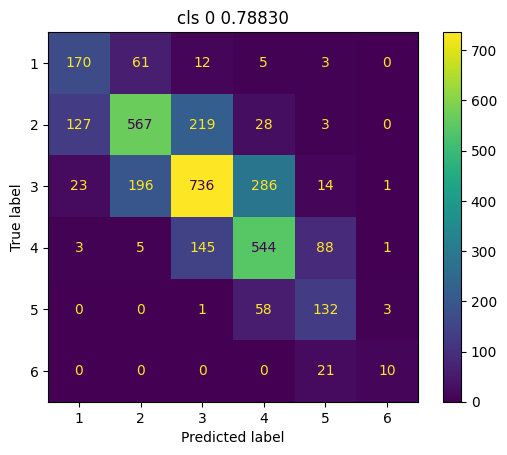

[LightGBM] [Info] Total Bins 74693
[LightGBM] [Info] Number of data points in the train set: 13845, number of used features: 5485
[LightGBM] [Info] Start training from score -1.791760
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.738463	test's QWK: 0.718284
[100]	train's QWK: 0.768858	test's QWK: 0.741118
[150]	train's QWK: 0.789822	test's QWK: 0.756919
[200]	train's QWK: 0.811185	test's QWK: 0.766111
[250]	train's QWK: 0.825752	test's QWK: 0.776502
[300]	train's QWK: 0.839985	test's QWK: 0.77905
[350]	train's QWK: 0.849262	test's QWK: 0.782212
[400]	train's QWK: 0.859379	test's QWK: 0.78688
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[450]	train's QWK: 0

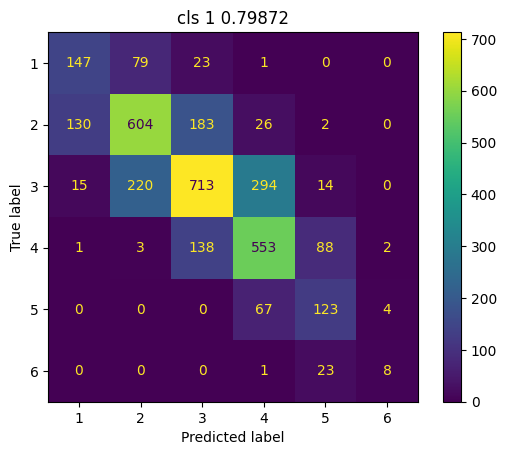

[LightGBM] [Info] Total Bins 74246
[LightGBM] [Info] Number of data points in the train set: 13846, number of used features: 5485
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[50]	train's QWK: 0.740054	test's QWK: 0.718103
[100]	train's QWK: 0.769432	test's QWK: 0.739731
[150]	train's QWK: 0.793529	test's QWK: 0.75792
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[200]	train's QWK: 0.809077	test's QWK: 0.75851
[250]	train's QWK: 0.82601	test's QWK: 0.76688
[300]	train's QWK: 0.837832	test's QWK: 0.766606
[350]	train's QWK: 0.848954	test's QWK: 0.771

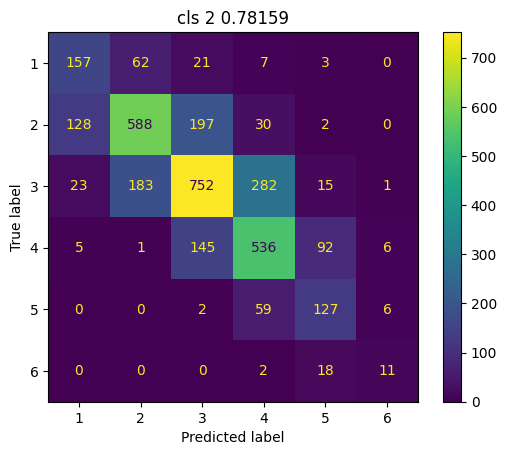

[LightGBM] [Info] Total Bins 74484
[LightGBM] [Info] Number of data points in the train set: 13846, number of used features: 5485
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.736592	test's QWK: 0.719459
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[100]	train's QWK: 0.767858	test's QWK: 0.738338
[150]	train's QWK: 0.792282	test's QWK: 0.75713
[200]	train's QWK: 0.808929	test's QWK: 0.763166
[250]	train's QWK: 0.824624	test's QWK: 0.771615
[300]	train's QWK: 0.836994	test's QWK: 0.775515
[350]	train's QWK: 0.847809	test's QWK: 0.7796
[LightGBM] [Warning] No further splits with positive gain, best gain: 

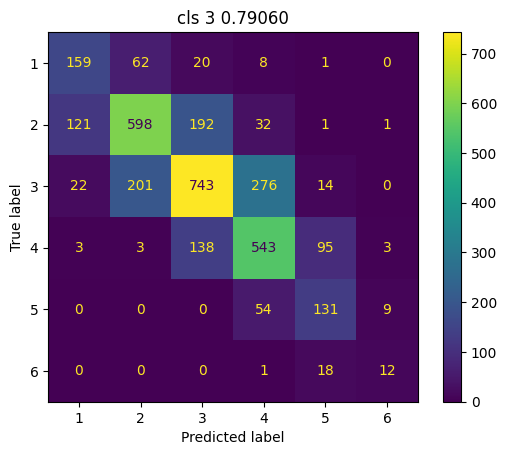

[LightGBM] [Info] Total Bins 74540
[LightGBM] [Info] Number of data points in the train set: 13846, number of used features: 5485
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.740234	test's QWK: 0.716713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[100]	train's QWK: 0.77093	test's QWK: 0.733419
[150]	train's QWK: 0.792731	test's QWK: 0.748068
[200]	train's QWK: 0.810935	test's QWK: 0.758072
[250]	train's QWK: 0.826854	test's QWK: 0.766555
[300]	train's QWK: 0.840532	test's QWK: 0.768833
[350]	train's QWK: 0.850319	test's QWK: 0.772474
[400]	train's QWK: 0.85985	test's QWK: 0.777644
[450]	train's QWK: 0

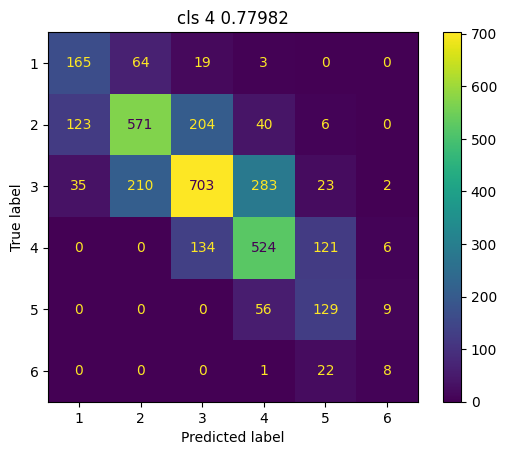

0.787734756352525
[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Total Bins 76245
[LightGBM] [Info] Number of data points in the train set: 13845, number of used features: 5491
[LightGBM] [Info] Using self-defined objective function
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.792911	test's QWK: 0.780156
[100]	train's QWK: 0.811764	test's QWK: 0.798799
[150]	train's QWK: 0.818612	test's QWK: 0.803508
[200]	train's QWK: 0.82174	test's QWK: 0.808791
[250]	train's QWK: 0.824411	test's QWK: 0.809147
[300]	train's QWK: 0.826599	test's QWK: 0.809044
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[241]	train's QWK: 0.824279	test's QWK: 0.809892
Evaluated only: QWK


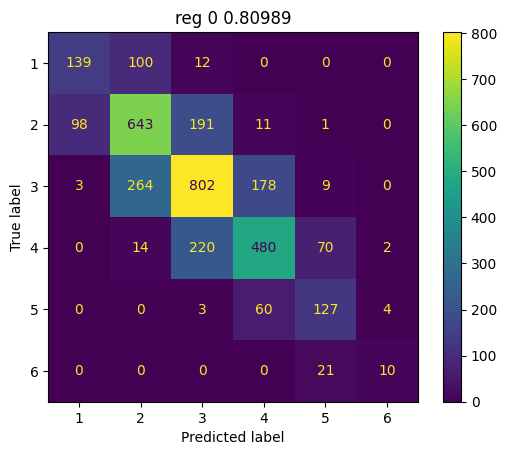

[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Total Bins 76223
[LightGBM] [Info] Number of data points in the train set: 13845, number of used features: 5491
[LightGBM] [Info] Using self-defined objective function
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.789949	test's QWK: 0.793253
[100]	train's QWK: 0.809427	test's QWK: 0.805326
[150]	train's QWK: 0.815927	test's QWK: 0.809523
[200]	train's QWK: 0.819571	test's QWK: 0.812903
[250]	train's QWK: 0.822579	test's QWK: 0.814046
[300]	train's QWK: 0.826807	test's QWK: 0.817345
[350]	train's QWK: 0.8294	test's QWK: 0.819412
[400]	train's QWK: 0.832099	test's QWK: 0.819935
[450]	train's QWK: 0.835168	test's QWK: 0.816791
[500]	train's QWK: 0.836355	test's QWK: 0.818066
Early stopping, best iteration is:
[410]	train's QWK: 0.832926	test's QWK: 0.820284
Evaluated only: QWK


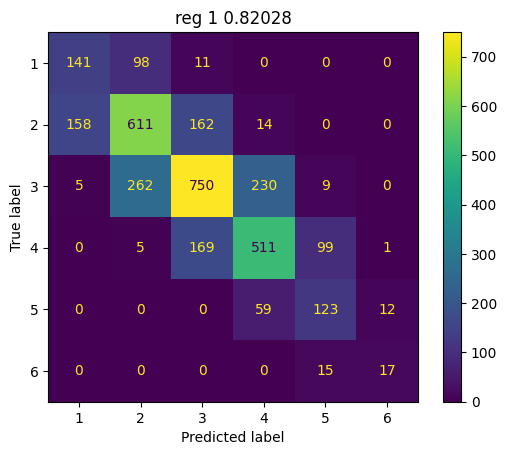

[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Total Bins 75776
[LightGBM] [Info] Number of data points in the train set: 13846, number of used features: 5491
[LightGBM] [Info] Using self-defined objective function
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.790843	test's QWK: 0.790649
[100]	train's QWK: 0.809035	test's QWK: 0.804732
[150]	train's QWK: 0.817341	test's QWK: 0.806614
[200]	train's QWK: 0.822163	test's QWK: 0.808526
[250]	train's QWK: 0.825142	test's QWK: 0.811413
[300]	train's QWK: 0.827922	test's QWK: 0.81332
[350]	train's QWK: 0.830009	test's QWK: 0.812567
[400]	train's QWK: 0.83173	test's QWK: 0.812762
Early stopping, best iteration is:
[306]	train's QWK: 0.828291	test's QWK: 0.813705
Evaluated only: QWK


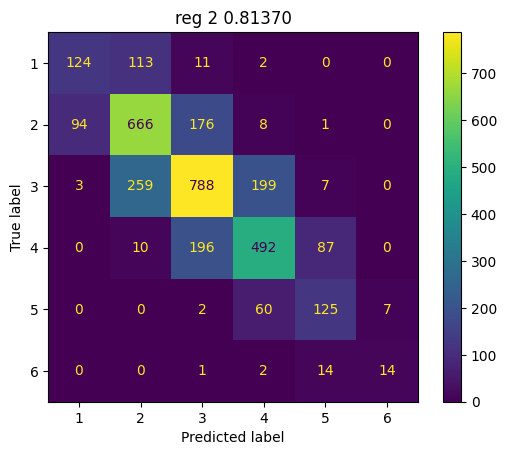

[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Total Bins 76014
[LightGBM] [Info] Number of data points in the train set: 13846, number of used features: 5491
[LightGBM] [Info] Using self-defined objective function
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.790091	test's QWK: 0.793858
[100]	train's QWK: 0.809511	test's QWK: 0.8103
[150]	train's QWK: 0.817658	test's QWK: 0.812958
[200]	train's QWK: 0.822361	test's QWK: 0.814852
[250]	train's QWK: 0.82548	test's QWK: 0.814835
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[300]	train's QWK: 0.828404	test's QWK: 0.816678
[350]	train's QWK: 0.830218	test's QWK: 0.817131
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[400]	train's QWK: 0.832464	test's QWK: 0.815296
Early stopping, best iteration is:
[335]	train's QWK: 0.829376	test's QWK: 0.818051

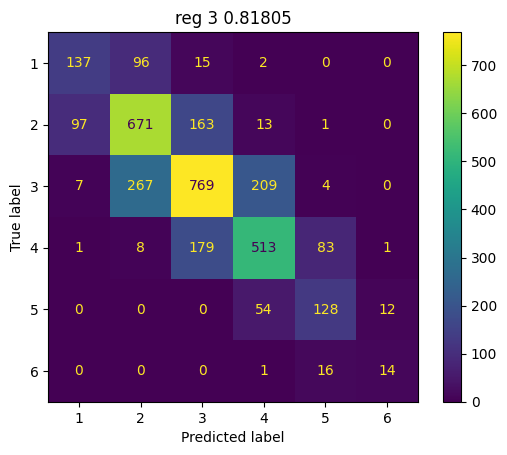

[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Total Bins 76070
[LightGBM] [Info] Number of data points in the train set: 13846, number of used features: 5491
[LightGBM] [Info] Using self-defined objective function
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.788875	test's QWK: 0.773285
[100]	train's QWK: 0.811667	test's QWK: 0.792622
[150]	train's QWK: 0.816984	test's QWK: 0.798531
[200]	train's QWK: 0.820954	test's QWK: 0.799969
[250]	train's QWK: 0.824483	test's QWK: 0.802719
[300]	train's QWK: 0.827715	test's QWK: 0.805776
[350]	train's QWK: 0.830521	test's QWK: 0.806623
[400]	train's QWK: 0.833093	test's QWK: 0.807701
[450]	train's QWK: 0.835281	test's QWK: 0.808654
[500]	train's QWK: 0.837237	test's QWK: 0.806443
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[446]	train's QWK: 0.835147	test's QWK: 0.808819
Evaluated only: QWK


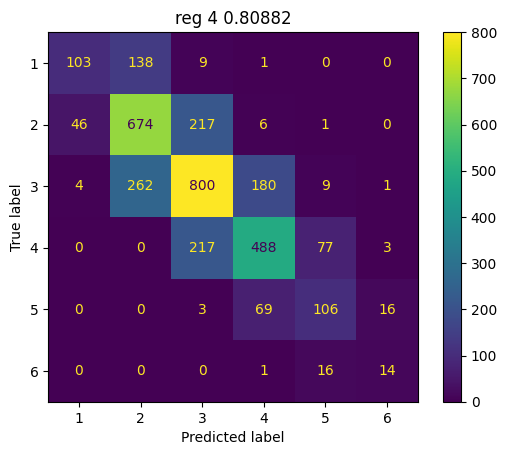

0.8142769299512969


In [10]:
if not FAST_TRAINING:
    cls_imps, pcls,prob = TRAINING(
        "classification",
        params.cls_param,
        params.cls_cb,
        quadratic_weighted_kappa_cls,
        params.path,
        Feats=Feats)

    print(cohen_kappa_score(tr["score"], pcls, weights = "quadratic")) # .787734756352525

    ## Adding Probabilities of Classifier for Regressor
    Feats = Feats.join(pd.DataFrame(prob, columns = [f"{i}_" for i in range(6)]))

    ## Training Regressor
    reg_imps, p = TRAINING(
        "regression",
        params.reg_param,
        params.reg_cb,
        quadratic_weighted_kappa,
        params.path,
        Feats=Feats)

    print(cohen_kappa_score(tr["score"], p.clip(1,6).round(), weights = "quadratic")) # .8142769299512969

In [11]:
if not FAST_TRAINING:
    ## Feature selection based upon Importance
    def Feature_Selection(imps, n, n_models):
        ex = imps[0]
        ex = ex[ex["imps"]>n].sort_values(by = "imps", ascending = False)

        for i in range(1,n_models):
            ex1 = imps[i]
            ex1 = ex1[ex1["imps"]>n].sort_values(by = "imps", ascending = False)
            ex = pd.concat([ex,ex1])

        ex = ex.sort_values(by = "imps", ascending = False)
        imps_ = ex.cols.unique()
        return imps_

    # Regressor Feature Selection
    all_reg_imps = Feature_Selection(reg_imps, 0, 5)

    # Classifier Feature Selection
    all_cls_imps = Feature_Selection(cls_imps, 5, 5)
    
    #Removing Probabilities of previous Classifier
    Feats = Feats.iloc[:, :-6]

In [12]:
if FAST_TRAINING:
    # Loading Important features for each model
    all_reg_imps = pickle.load(open("/kaggle/input/lgbm-v42/cpu_lgbmV42/all_reg_imps.pkl", "rb"))
    all_cls_imps = pickle.load(open("/kaggle/input/lgbm-v42/cpu_lgbmV42/all_cls_imps.pkl", "rb"))

[LightGBM] [Info] Total Bins 61238
[LightGBM] [Info] Number of data points in the train set: 13845, number of used features: 3671
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791760
Training until validation scores don't improve for 75 rounds
[50]	train's QWK: 0.738178	test's QWK: 0.720317
[100]	train's QWK: 0.769581	test's QWK: 0.73905
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[150]	train's QWK: 0.791918	test's QWK: 0.754387
[200]	train's QWK: 0.809145	test's QWK: 0.764582
[250]	train's QWK: 0.825369	test's QWK: 0.771105
[300]	train's QWK: 0.837423	test's QWK: 0.777618
[350]	train's QWK: 0.847186	test's QWK: 0.786318
[400]	train's QWK: 0.85473	test's QWK: 0.785879
[LightGBM] [Warning] 

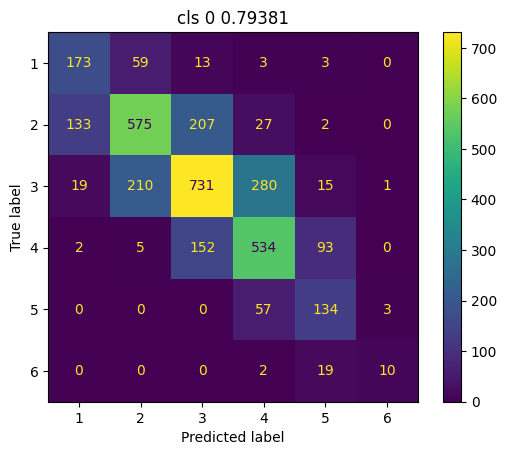

[LightGBM] [Info] Total Bins 61189
[LightGBM] [Info] Number of data points in the train set: 13845, number of used features: 3671
[LightGBM] [Info] Start training from score -1.791760
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
Training until validation scores don't improve for 75 rounds
[50]	train's QWK: 0.737087	test's QWK: 0.722036
[100]	train's QWK: 0.767243	test's QWK: 0.740429
[150]	train's QWK: 0.78984	test's QWK: 0.753827
[200]	train's QWK: 0.807058	test's QWK: 0.765025
[250]	train's QWK: 0.822704	test's QWK: 0.769853
[300]	train's QWK: 0.836788	test's QWK: 0.779328
[350]	train's QWK: 0.846773	test's QWK: 0.78244
[400]	train's QWK: 0.856035	test's QWK: 0.781862
[450]	train's QWK: 0.864021	test's QWK: 0.78508
[LightGBM] [Warning] No further splits with posi

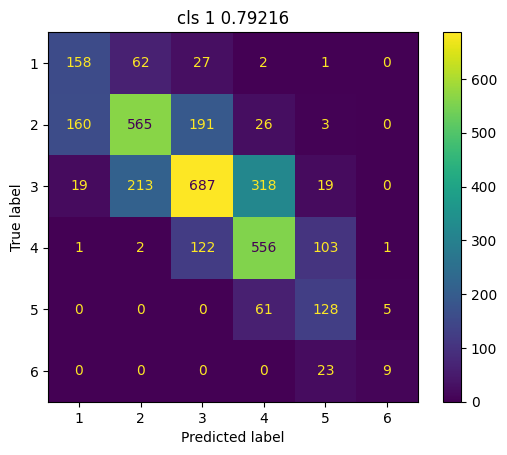

[LightGBM] [Info] Total Bins 60802
[LightGBM] [Info] Number of data points in the train set: 13846, number of used features: 3671
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
Training until validation scores don't improve for 75 rounds
[50]	train's QWK: 0.73765	test's QWK: 0.717501
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[100]	train's QWK: 0.769586	test's QWK: 0.734956
[150]	train's QWK: 0.792044	test's QWK: 0.752793
[200]	train's QWK: 0.810499	test's QWK: 0.763507
[250]	train's QWK: 0.826054	test's QWK: 0.765937
[300]	train's QWK: 0.837341	test's QWK: 0.770019
[350]	train's QWK: 0.847187	test's QWK: 0.772537
[400]	train's QWK: 0.856972	test's QWK: 0.776513
[450]	train's QWK: 0

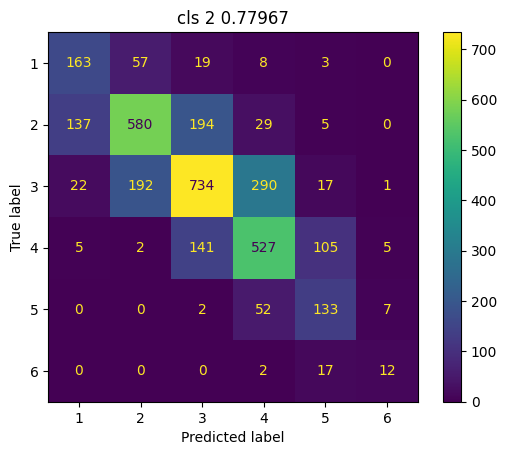

[LightGBM] [Info] Total Bins 61024
[LightGBM] [Info] Number of data points in the train set: 13846, number of used features: 3671
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
Training until validation scores don't improve for 75 rounds
[50]	train's QWK: 0.736356	test's QWK: 0.726502
[100]	train's QWK: 0.767705	test's QWK: 0.744756
[150]	train's QWK: 0.792047	test's QWK: 0.758032
[200]	train's QWK: 0.808019	test's QWK: 0.764963
[250]	train's QWK: 0.823675	test's QWK: 0.771135
[300]	train's QWK: 0.835092	test's QWK: 0.7761
[350]	train's QWK: 0.847395	test's QWK: 0.782183
[400]	train's QWK: 0.857547	test's QWK: 0.785547
[450]	train's QWK: 0.865062	test's QWK: 0.786181
[LightGBM] [Warning] No further splits with pos

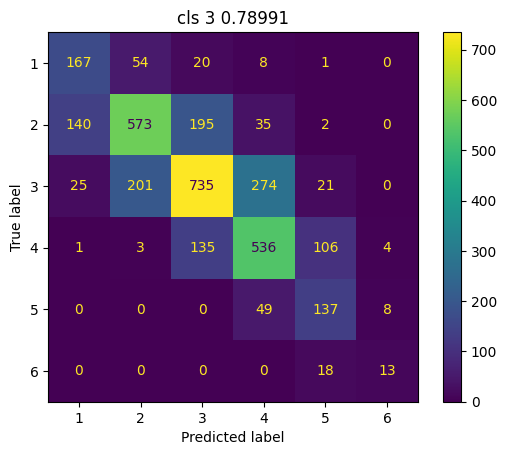

[LightGBM] [Info] Total Bins 61143
[LightGBM] [Info] Number of data points in the train set: 13846, number of used features: 3671
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
Training until validation scores don't improve for 75 rounds
[50]	train's QWK: 0.74028	test's QWK: 0.714508
[100]	train's QWK: 0.770278	test's QWK: 0.733059
[150]	train's QWK: 0.794454	test's QWK: 0.748684
[200]	train's QWK: 0.810893	test's QWK: 0.758343
[250]	train's QWK: 0.826206	test's QWK: 0.765647
[300]	train's QWK: 0.839122	test's QWK: 0.771423
[350]	train's QWK: 0.849183	test's QWK: 0.774687
[400]	train's QWK: 0.857923	test's QWK: 0.777519
[450]	train's QWK: 0.86528	test's QWK: 0.780519
[LightGBM] [Warning] No further splits with pos

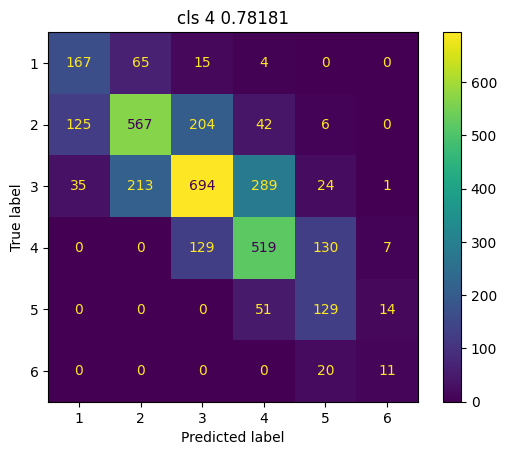

0.7874222591863567
[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Total Bins 54595
[LightGBM] [Info] Number of data points in the train set: 13845, number of used features: 2830
[LightGBM] [Info] Using self-defined objective function
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.789471	test's QWK: 0.780559
[100]	train's QWK: 0.810175	test's QWK: 0.803622
[150]	train's QWK: 0.818259	test's QWK: 0.807258
[200]	train's QWK: 0.823946	test's QWK: 0.810513
[250]	train's QWK: 0.826029	test's QWK: 0.811992
[300]	train's QWK: 0.828782	test's QWK: 0.811111
[350]	train's QWK: 0.830734	test's QWK: 0.813624
[400]	train's QWK: 0.833099	test's QWK: 0.814903
[450]	train's QWK: 0.83506	test's QWK: 0.816054
[500]	train's QWK: 0.837162	test's QWK: 0.815922
[550]	train's QWK: 0.838714	test's QWK: 0.816681
[600]	train's QWK: 0.839911	test's QWK: 0.815441
Early stopping, best iteration is:
[546]	train's QWK: 0.838703	test's QWK: 0.817557
Evaluat

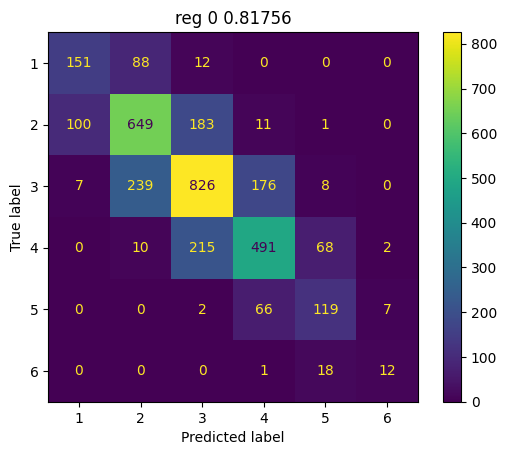

[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Total Bins 54534
[LightGBM] [Info] Number of data points in the train set: 13845, number of used features: 2830
[LightGBM] [Info] Using self-defined objective function
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.786359	test's QWK: 0.785868
[100]	train's QWK: 0.809121	test's QWK: 0.802336
[150]	train's QWK: 0.81809	test's QWK: 0.809911
[200]	train's QWK: 0.822769	test's QWK: 0.812095
[250]	train's QWK: 0.825723	test's QWK: 0.812719
[300]	train's QWK: 0.829563	test's QWK: 0.814421
[350]	train's QWK: 0.832531	test's QWK: 0.816105
[400]	train's QWK: 0.834727	test's QWK: 0.815268
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[347]	train's QWK: 0.83227	test's QWK: 0.816866
Evaluated only: QWK


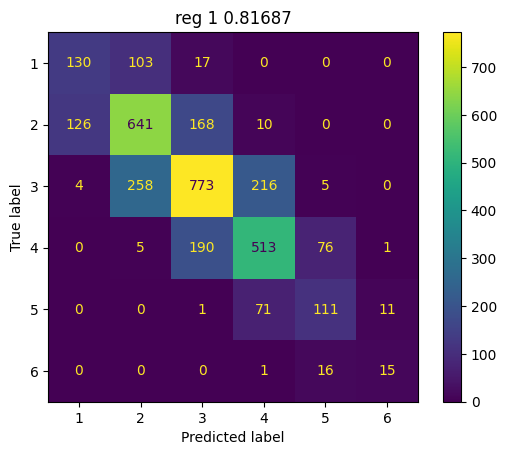

[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Total Bins 54218
[LightGBM] [Info] Number of data points in the train set: 13846, number of used features: 2830
[LightGBM] [Info] Using self-defined objective function
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.789146	test's QWK: 0.781003
[100]	train's QWK: 0.807631	test's QWK: 0.801177
[150]	train's QWK: 0.816016	test's QWK: 0.808147
[200]	train's QWK: 0.821095	test's QWK: 0.80888
[250]	train's QWK: 0.824604	test's QWK: 0.811066
[300]	train's QWK: 0.827871	test's QWK: 0.810793
[350]	train's QWK: 0.830417	test's QWK: 0.811259
[400]	train's QWK: 0.832656	test's QWK: 0.8106
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[450]	train's QWK: 0.83414	test's QWK: 0.810951
[500]	train's QWK: 0.836042	test's QWK: 0.812698
[550]	train's QWK: 0.83817	test's QWK: 0.814491
[600]	train's QWK: 0.840281	test's QWK: 0.815019
[650]	train's QWK: 0.841635	test's QWK:

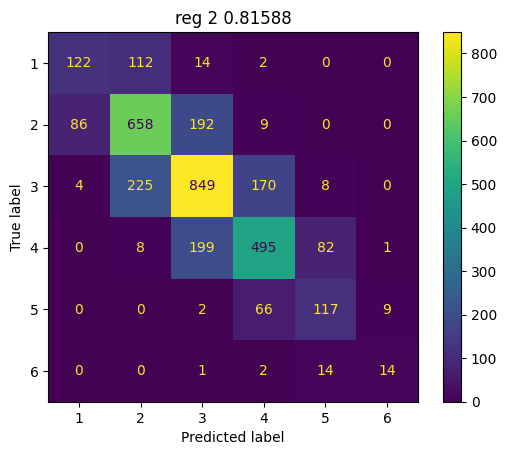

[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Total Bins 54407
[LightGBM] [Info] Number of data points in the train set: 13846, number of used features: 2830
[LightGBM] [Info] Using self-defined objective function
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.788156	test's QWK: 0.794057
[100]	train's QWK: 0.808462	test's QWK: 0.807806
[150]	train's QWK: 0.815067	test's QWK: 0.813977
[200]	train's QWK: 0.819848	test's QWK: 0.81482
[250]	train's QWK: 0.823303	test's QWK: 0.817827
[300]	train's QWK: 0.826905	test's QWK: 0.817729
[350]	train's QWK: 0.828609	test's QWK: 0.817641
[400]	train's QWK: 0.830709	test's QWK: 0.817303
Early stopping, best iteration is:
[345]	train's QWK: 0.828603	test's QWK: 0.818831
Evaluated only: QWK


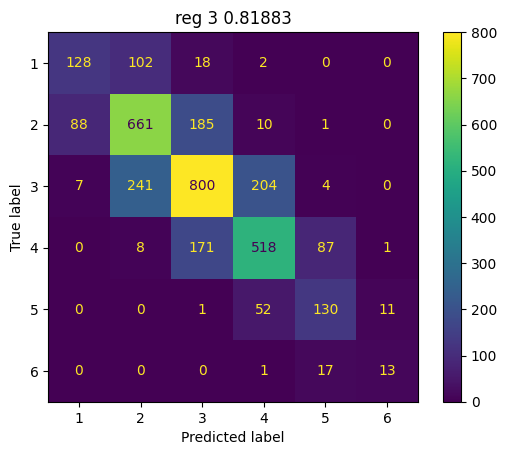

[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Total Bins 54483
[LightGBM] [Info] Number of data points in the train set: 13846, number of used features: 2830
[LightGBM] [Info] Using self-defined objective function
Training until validation scores don't improve for 100 rounds
[50]	train's QWK: 0.788304	test's QWK: 0.776652
[100]	train's QWK: 0.810144	test's QWK: 0.797214
[150]	train's QWK: 0.817518	test's QWK: 0.803598
[200]	train's QWK: 0.82237	test's QWK: 0.804146
[250]	train's QWK: 0.824973	test's QWK: 0.804535
[300]	train's QWK: 0.8286	test's QWK: 0.80655
[350]	train's QWK: 0.830751	test's QWK: 0.806708
[400]	train's QWK: 0.833143	test's QWK: 0.807314
[450]	train's QWK: 0.835134	test's QWK: 0.807581
[500]	train's QWK: 0.836745	test's QWK: 0.808568
[550]	train's QWK: 0.838356	test's QWK: 0.809274
[600]	train's QWK: 0.840033	test's QWK: 0.809406
Early stopping, best iteration is:
[527]	train's QWK: 0.837432	test's QWK: 0.810198
Evaluated only: QWK


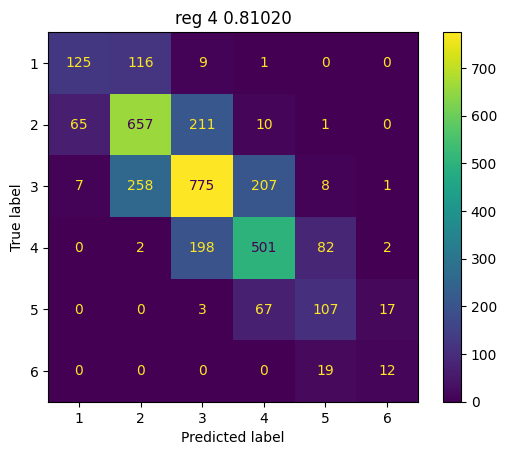

0.8158797934798527


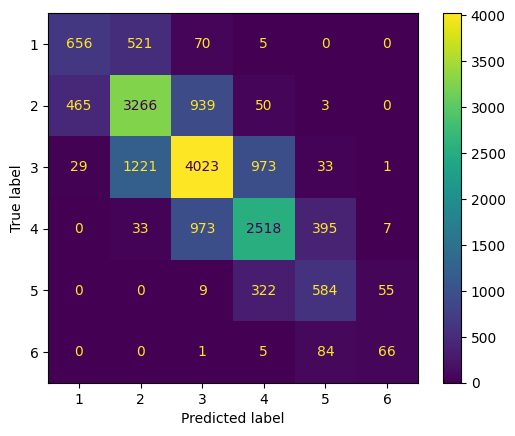

In [13]:
# Selecting only Important classifier features
FeatsC = Feats.loc[:, all_cls_imps].copy()

# Training Model again, NOTE: New Callback with EarlyStopping=75
cls_imps, pcls,prob = TRAINING(
    "classification",
    params.cls_param,
    params.cls_cb2,
    quadratic_weighted_kappa_cls,
    params.path,
    Feats=FeatsC)

print(cohen_kappa_score(tr["score"], pcls, weights = "quadratic")) # 0.7874222591863567

# Adding Probabilities of Classifier 
Feats = Feats.join(pd.DataFrame(prob, columns = [f"{i}_" for i in range(6)]))

# Selecting only important features for Regressor
Feats = Feats.loc[:, all_reg_imps]

reg_imps, p = TRAINING(
    "regression",
    params.reg_param,
    params.reg_cb,
    quadratic_weighted_kappa,
    params.path,
    Feats=Feats)

print(cohen_kappa_score(tr["score"], p.clip(1,6).round(), weights = "quadratic")) # 0.8158797934798527
cm = confusion_matrix(tr["score"], p.clip(1,6).round())
ConfusionMatrixDisplay(cm, display_labels = [i for i in range(1,7)]).plot()